First 5 Rows:
   laufkont  laufzeit  moral  verw  hoehe  sparkont  beszeit  rate  famges  \
0         1        18      4     2   1049         1        2     4       2   
1         1         9      4     0   2799         1        3     2       3   
2         2        12      2     9    841         2        4     2       2   
3         1        12      4     0   2122         1        3     3       3   
4         1        12      4     0   2171         1        3     4       3   

   buerge  ...  verm  alter  weitkred  wohn  bishkred  beruf  pers  telef  \
0       1  ...     2     21         3     1         1      3     2      1   
1       1  ...     1     36         3     1         2      3     1      1   
2       1  ...     1     23         3     1         1      2     2      1   
3       1  ...     1     39         3     1         2      2     1      1   
4       1  ...     2     38         1     2         2      2     2      1   

   gastarb  kredit  
0        2       1  
1        2  

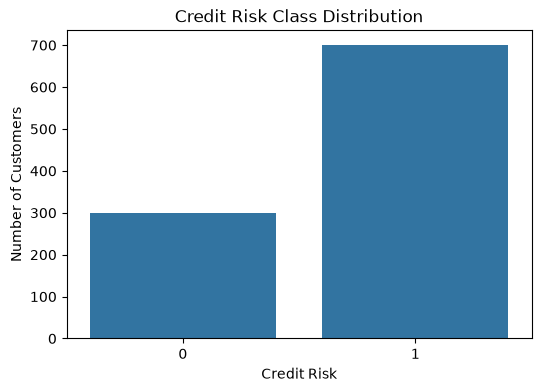


Personal Status Representation:
pers
2    845
1    155
Name: count, dtype: int64


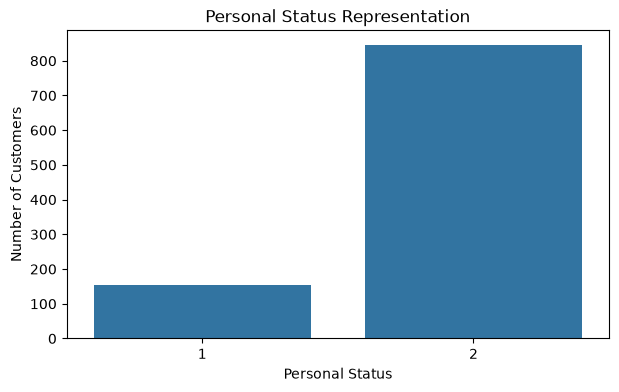


Credit Risk by Personal Status:
kredit    0    1
pers            
1        46  109
2       254  591


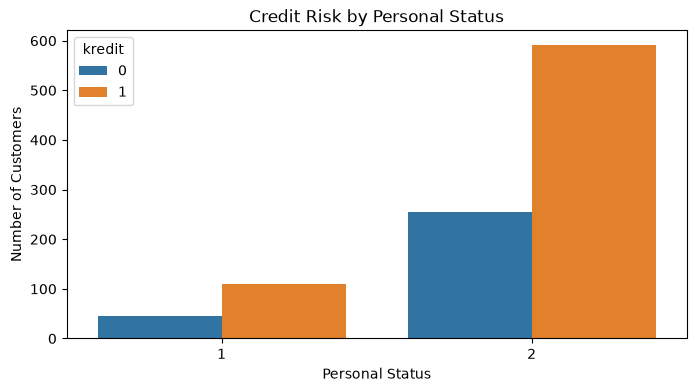


Age Group Representation:
AgeGroup
Young          190
Adult          397
Middle-aged    300
Senior          95
Elderly         18
Name: count, dtype: int64


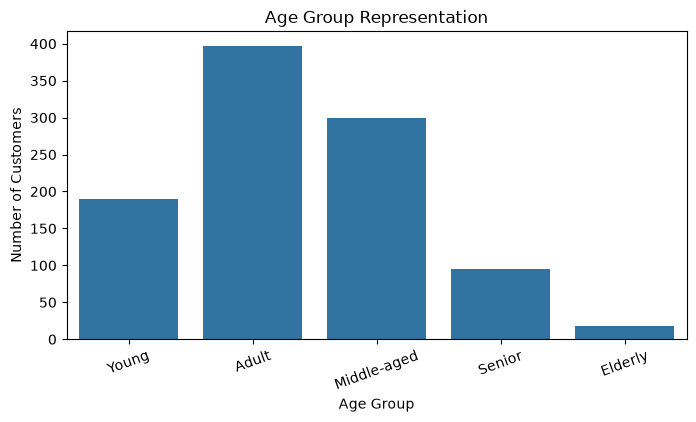


Credit Risk by Age Group:
kredit         0    1
AgeGroup             
Young         80  110
Adult        118  279
Middle-aged   71  229
Senior        26   69
Elderly        5   13


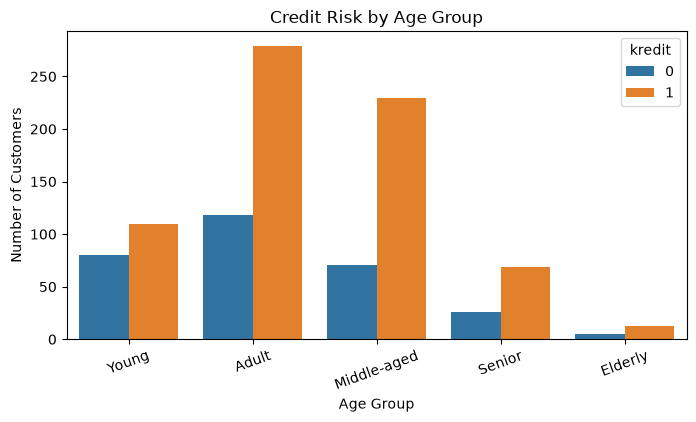


Housing Category Representation:
wohn
2    714
1    179
3    107
Name: count, dtype: int64


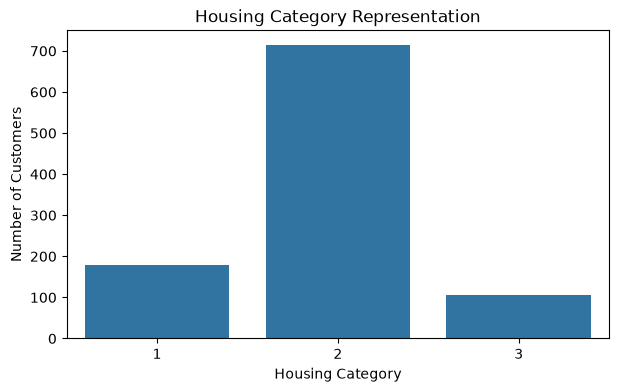


Credit Risk by Housing Category:
kredit    0    1
wohn            
1        70  109
2       186  528
3        44   63


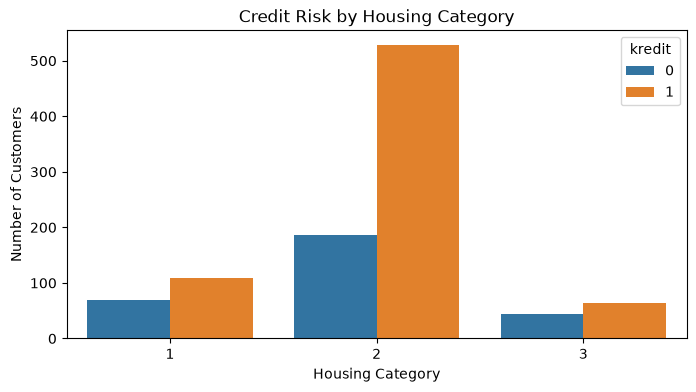


Possible Bias:
- Different personal-status groups may have unequal representation.
- Age groups may not be equally represented.
- Housing categories may have unequal representation.
- Credit risk classes may be imbalanced.

Impact on Machine Learning:
- The model may favor the majority credit-risk class.
- Underrepresented groups may receive less accurate predictions.
- Age and personal status may influence predictions.
- Housing information may affect credit-risk predictions.

Suggested Solutions:
- Handle missing values properly.
- Use class balancing techniques.
- Use stratified train-test splitting.
- Evaluate model performance for different groups.
- Use fairness metrics to identify bias.
- Remove unnecessary sensitive features when appropriate.

Final Conclusion:
The German Credit dataset contains differences in credit risk
across personal status, age and housing categories.
These differences can influence machine learning predictions.
Proper preprocessing, balancing and fairnes

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("german_credit_data.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# 1. Load and Explore Dataset
print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())


# 2. Check Data Quality
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# 3. Identify Target Variable
target = "kredit"
print("\nTarget Variable:", target)


# 4. Analyze Class Distribution
print("\nCredit Risk Distribution:")
print(df["kredit"].value_counts())
print("\nCredit Risk Percentage:")
print(df["kredit"].value_counts(normalize=True) * 100)


# 5. Visualize Class Imbalance
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="kredit")
plt.title("Credit Risk Class Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()


# 6. Analyze Gender / Personal Status Representation
print("\nPersonal Status Representation:")
print(df["pers"].value_counts())
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="pers")
plt.title("Personal Status Representation")
plt.xlabel("Personal Status")
plt.ylabel("Number of Customers")
plt.show()


# 7. Analyze Credit Risk by Personal Status
print("\nCredit Risk by Personal Status:")
print(pd.crosstab(df["pers"], df["kredit"]))
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="pers", hue="kredit")
plt.title("Credit Risk by Personal Status")
plt.xlabel("Personal Status")
plt.ylabel("Number of Customers")
plt.show()


# 8. Analyze Age Groups
df["AgeGroup"] = pd.cut(
    df["alter"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["Young", "Adult", "Middle-aged", "Senior", "Elderly"]
)
print("\nAge Group Representation:")
print(df["AgeGroup"].value_counts().sort_index())
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="AgeGroup")
plt.title("Age Group Representation")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()


# 9. Analyze Credit Risk by Age Group
print("\nCredit Risk by Age Group:")
print(pd.crosstab(df["AgeGroup"], df["kredit"]))
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="AgeGroup", hue="kredit")
plt.title("Credit Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()


# 10. Analyze Housing Category Representation
print("\nHousing Category Representation:")
print(df["wohn"].value_counts())
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="wohn")
plt.title("Housing Category Representation")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()


# 11. Analyze Credit Risk by Housing Category
print("\nCredit Risk by Housing Category:")
print(pd.crosstab(df["wohn"], df["kredit"]))
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="wohn", hue="kredit")
plt.title("Credit Risk by Housing Category")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()


# 12. Identify Possible Bias
print("\nPossible Bias:")
print("- Different personal-status groups may have unequal representation.")
print("- Age groups may not be equally represented.")
print("- Housing categories may have unequal representation.")
print("- Credit risk classes may be imbalanced.")


# 13. Impact on ML
print("\nImpact on Machine Learning:")
print("- The model may favor the majority credit-risk class.")
print("- Underrepresented groups may receive less accurate predictions.")
print("- Age and personal status may influence predictions.")
print("- Housing information may affect credit-risk predictions.")


# 14. Suggested Solutions
print("\nSuggested Solutions:")
print("- Handle missing values properly.")
print("- Use class balancing techniques.")
print("- Use stratified train-test splitting.")
print("- Evaluate model performance for different groups.")
print("- Use fairness metrics to identify bias.")
print("- Remove unnecessary sensitive features when appropriate.")


# 15. Final Conclusion

print("\nFinal Conclusion:")
print("The German Credit dataset contains differences in credit risk")
print("across personal status, age and housing categories.")
print("These differences can influence machine learning predictions.")
print("Proper preprocessing, balancing and fairness evaluation")
print("can help build a more reliable and fair model.")